Linear: MSE=0.0794, R²=0.3854
Cubic:  MSE=0.0780, R²=0.3962


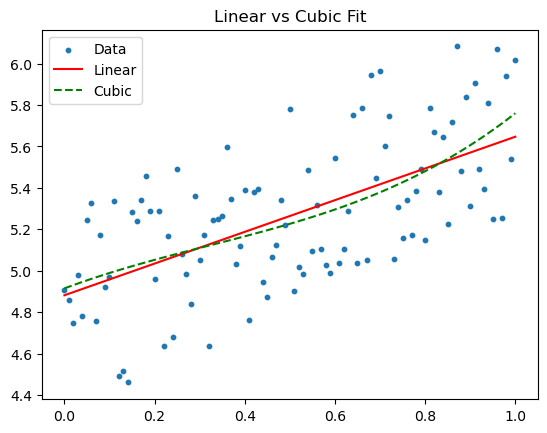

Degree  1: MSE=0.0794, R²=0.3854
Degree  2: MSE=0.0782, R²=0.3942
Degree  3: MSE=0.0780, R²=0.3962
Degree  4: MSE=0.0778, R²=0.3974
Degree  5: MSE=0.0778, R²=0.3976
Degree  6: MSE=0.0775, R²=0.4001
Degree  7: MSE=0.0773, R²=0.4015
Degree  8: MSE=0.0772, R²=0.4025
Degree  9: MSE=0.0769, R²=0.4048
Degree 10: MSE=0.0760, R²=0.4118


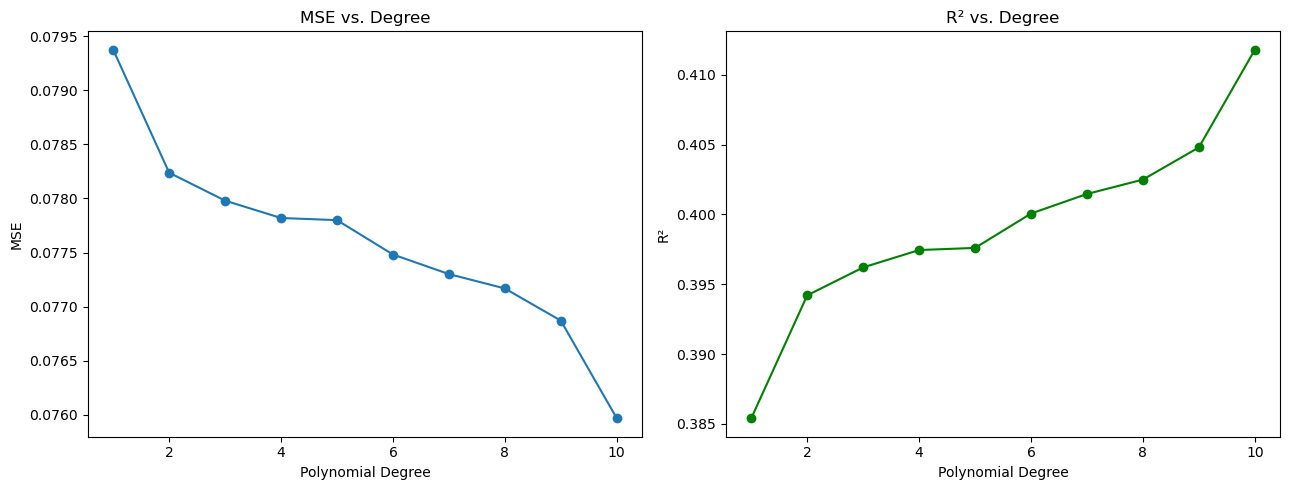


Vandermonde Polynomial Fit Results:
  Degree  1: MSE=0.0794, R²=0.3854
  Degree  3: MSE=0.0780, R²=0.3962
  Degree 10: MSE=0.0760, R²=0.4118


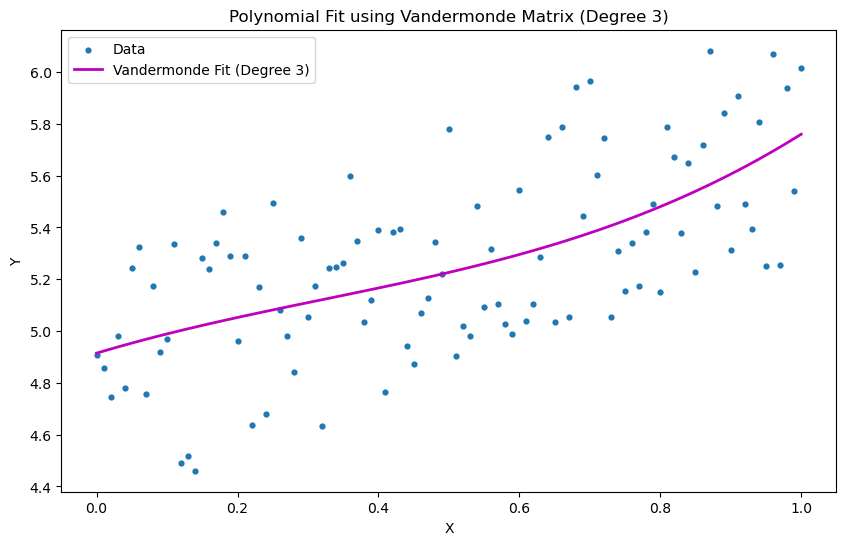

In [1]:
# Part A

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(0)
m_true, b_true = np.random.uniform(-10, 10, 2)
X = np.arange(0, 1.01, 0.01)
Y = m_true * X + b_true + np.random.uniform(0, 1, X.size)

def least_squares(X, Y):
    m = np.cov(X, Y, bias=True)[0, 1] / np.var(X)
    b = np.mean(Y) - m * np.mean(X)
    return m, b

def vandermonde_fit(X, Y, deg):
    V = np.vander(X, deg+1)
    coeffs, *_ = np.linalg.lstsq(V, Y, rcond=None)
    return np.polyval(coeffs, X), coeffs

m_lsm, b_lsm = least_squares(X, Y)
Y_lin = m_lsm * X + b_lsm
Y_cub = np.polyval(np.polyfit(X, Y, 3), X)
metrics = lambda y, yhat: (mean_squared_error(y, yhat), r2_score(y, yhat))
mse_lin, r2_lin = metrics(Y, Y_lin)
mse_cub, r2_cub = metrics(Y, Y_cub)
print(f"Linear: MSE={mse_lin:.4f}, R²={r2_lin:.4f}")
print(f"Cubic:  MSE={mse_cub:.4f}, R²={r2_cub:.4f}")
plt.scatter(X, Y, s=10, label='Data')
plt.plot(X, Y_lin, 'r-', label='Linear')
plt.plot(X, Y_cub, 'g--', label='Cubic')
plt.legend(); plt.title("Linear vs Cubic Fit"); plt.show()

# Part B 
mse_list = []
r2_list = []
degrees = range(1, 11)
fits = []

for d in degrees:
    coeffs = np.polyfit(X, Y, d)
    Y_pred = np.polyval(coeffs, X)
    mse = mean_squared_error(Y, Y_pred)
    r2 = r2_score(Y, Y_pred)
    mse_list.append(mse)
    r2_list.append(r2)
    fits.append(Y_pred)
    print(f"Degree {d:2d}: MSE={mse:.4f}, R²={r2:.4f}")

plt.figure(figsize=(13, 5))
plt.subplot(1, 2, 1)
plt.plot(degrees, mse_list, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('MSE vs. Degree')
plt.subplot(1, 2, 2)
plt.plot(degrees, r2_list, marker='o', color='green')
plt.xlabel('Polynomial Degree')
plt.ylabel('R²')
plt.title('R² vs. Degree')
plt.tight_layout()
plt.show()

# Part C
from numpy.linalg import lstsq

def vandermonde_fit(X, Y, degree):
    V = np.vander(X, degree+1)
    coeffs, *_ = lstsq(V, Y, rcond=None)
    Y_pred = V @ coeffs
    return Y_pred, coeffs

print("\nVandermonde Polynomial Fit Results:")
for d in [1, 3, 10]:
    Y_pred, coeffs = vandermonde_fit(X, Y, d)
    mse = mean_squared_error(Y, Y_pred)
    r2 = r2_score(Y, Y_pred)
    print(f"  Degree {d:2d}: MSE={mse:.4f}, R²={r2:.4f}")

Y_vand_cubic, _ = vandermonde_fit(X, Y, 3)
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, label='Data', s=12)
plt.plot(X, Y_vand_cubic, 'm-', label='Vandermonde Fit (Degree 3)', linewidth=2)
plt.title('Polynomial Fit using Vandermonde Matrix (Degree 3)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()